### Importation des librairies 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import csv
import os
import pickle
from matplotlib.ticker import MultipleLocator
import xarray as xr

### Importation des fichiers 3D

In [2]:
data_cli = xr.open_dataset("3D/MESONH_RCE_small300_3D_cli.nc") #glace nuageuse
data_clw = xr.open_dataset("3D/MESONH_RCE_small300_3D_clw.nc") #eau liquide nuageuse
data_hur = xr.open_dataset("3D/MESONH_RCE_small300_3D_hur.nc") #humidité relative
data_hus = xr.open_dataset("3D/MESONH_RCE_small300_3D_hus.nc") #humidité spécifique
data_pa = xr.open_dataset("3D/MESONH_RCE_small300_3D_pa.nc") #pression atmosphérique 
data_pli = xr.open_dataset("3D/MESONH_RCE_small300_3D_pli.nc") #glace précipitante
data_plw = xr.open_dataset("3D/MESONH_RCE_small300_3D_plw.nc") #eau liquide précipitante
data_ta = xr.open_dataset("3D/MESONH_RCE_small300_3D_ta.nc") #température atmosphérique
data_tntr = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntr.nc") #tendance des températures(radiative)
data_tntrl = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrl.nc") #tendance des températures(radiative longwave)
data_tntrs = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrs.nc") #tendance des températures(radiative shortwave)
data_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc") #vitesse de l air
data_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc") #vitesse de l air
data_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc") #vitesse de l air verticale

In [3]:
print(data_clw)
print(data_tntr)

<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    clw       (time, altitude, y, x) float32 296MB ...
<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    tntr      (time, altitude, y, x) float32 296MB ...


On a une grille horizontale de 100 par 100. L'altitude est découpée en 74 couches et le modèle a enregistré 100 moments différents.

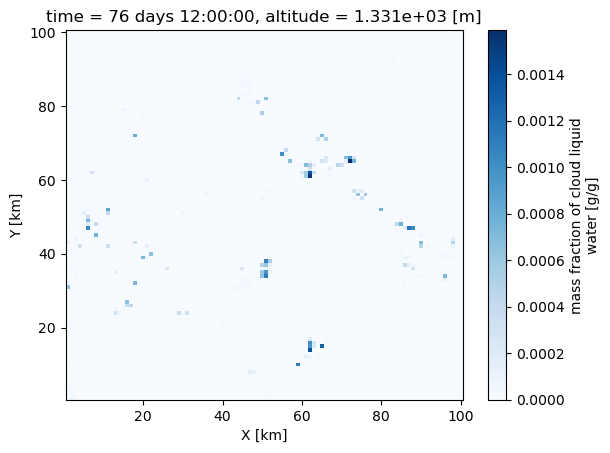

In [4]:
data_clw['clw'].isel(time=5, altitude=10).plot(cmap = 'Blues')

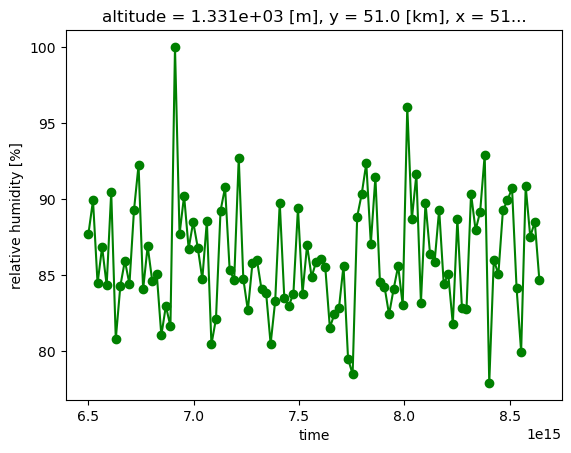

In [5]:
data_hur['hur'].isel(x=50, y=50, altitude=10).plot(marker='o', color='green')

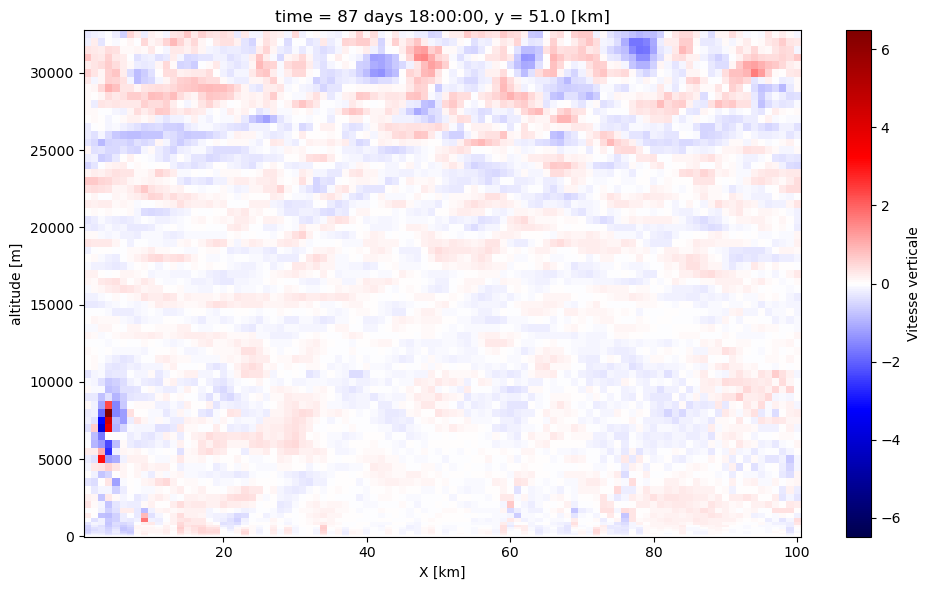

In [6]:
time_index = 50
y_index = 50
coupe_verticale_wa = data_wa['wa'].isel(time=time_index, y=y_index)
plt.figure(figsize=(10,6))
plot = coupe_verticale_wa.plot(x='x', y='altitude', cmap='seismic', cbar_kwargs={'label':'Vitesse verticale'})
plt.tight_layout()
plt.show()

### Exemple 1D

In [9]:
data_clw_1D = xr.open_dataset("1D/MESONH_RCE_small300_1D_clw_avg.nc") #eau liquide nuageuse
print(data_clw_1D)

<xarray.Dataset> Size: 730kB
Dimensions:   (time: 2400, altitude: 74)
Coordinates:
  * time      (time) timedelta64[ns] 19kB 01:00:00.000107285 ... 100 days 00:...
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
Data variables:
    clw_avg   (time, altitude) float32 710kB ...
